In [ ]:
!rm -rf /content/drive
!mkdir /content/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'DR_New_Results', 'Dataset']


In [ ]:
# checkpoint_path defined here; actual load runs after model init
checkpoint_path = "/content/drive/MyDrive/checkpoint.pth"
start_epoch = 0
# Actual loading happens in the post-model cell below

In [ ]:
!pip install timm imbalanced-learn
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
import matplotlib.cm as cm

In [ ]:
import os

# =========================
# PATHS
# =========================
USE_DRIVE = True   # 🔥 Change to False if you don't want Drive

if USE_DRIVE:
    RESULT_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"
else:
    RESULT_PATH = "/content/DR_New_Results/APTOS"

# =========================
# CREATE FOLDER
# =========================
os.makedirs(RESULT_PATH, exist_ok=True)

print("Saving results at:", RESULT_PATH)

Saving results at: /content/drive/MyDrive/DR_New_Results/APTOS


**Reproducibility and Seed Configuration**

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

**IDRiD Dataset Loading and Path Mapping**

In [ ]:
import os
import pandas as pd

# =========================
# IDRID DATASET PATHS
# =========================
idrid_root = (
    "/content/drive/MyDrive/"
    "Dataset/IDRiD/Train"
)

csv_path = os.path.join(
    idrid_root,
    "annotations.csv"
)

image_folder = os.path.join(
    idrid_root,
    "images"
)

# =========================
# LOAD ANNOTATIONS
# =========================
idrid_df = pd.read_csv(
    csv_path
)

idrid_df.rename(
    columns={
        "Retinopathy grade": "label"
    },
    inplace=True
)

# =========================
# BUILD IMAGE DICTIONARY
# =========================
image_dict = {

    os.path.splitext(file)[0]
    .strip()
    .lower():

    os.path.join(
        image_folder,
        file
    )

    for file in os.listdir(image_folder)

    if file.lower().endswith(
        (
            ".jpg",
            ".png",
            ".jpeg"
        )
    )
}

# =========================
# FIND IMAGE PATH
# =========================
def find_image(name):

    name = (
        os.path.splitext(
            str(name)
            .strip()
            .lower()
        )[0]
    )

    return image_dict.get(
        name,
        None
    )

# =========================
# MAP IMAGE PATHS
# =========================
idrid_df["image_path"] = idrid_df[
    "Image name"
].apply(find_image)

# =========================
# REMOVE MISSING PATHS
# =========================
idrid_df = idrid_df.dropna(
    subset=["image_path"]
).reset_index(drop=True)

# =========================
# DISPLAY DATASET INFO
# =========================
print(
    "Dataset loaded:",
    len(idrid_df)
)

print(
    "\nClass distribution:\n",
    idrid_df["label"].value_counts()
)

Dataset loaded: 1239

Class distribution:
 label
2    408
0    402
3    222
4    147
1     60
Name: count, dtype: int64


**IDRiD Dataset Distribution Visualization**

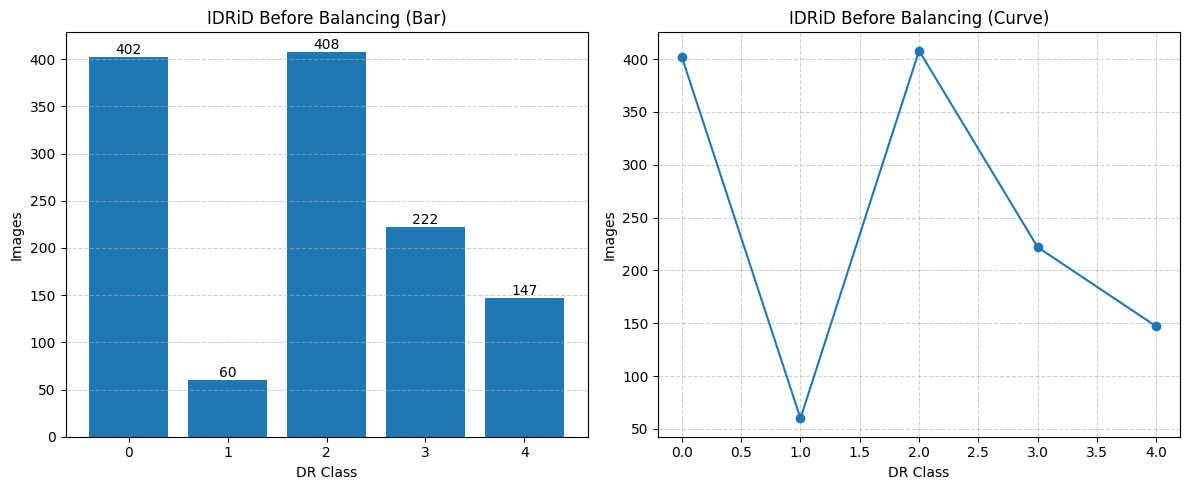


✅ Saved at: /content/drive/MyDrive/DR_New_Results/IDRiD/final_distribution_bar_curve.png


In [ ]:
import matplotlib.pyplot as plt
import os

# =========================
# CLASS DISTRIBUTION
# =========================
before_counts = idrid_df[
    "label"
].value_counts().sort_index()

# =========================
# ADD VALUE LABELS
# =========================
def add_labels(ax):

    for patch in ax.patches:

        height = patch.get_height()

        ax.annotate(

            f'{int(height)}',

            (
                patch.get_x()
                + patch.get_width() / 2,

                height
            ),

            ha='center',

            va='bottom',

            fontsize=10
        )

# =========================
# PLOT CONFIGURATION
# =========================
plot_configs = [

    (
        "bar",
        "IDRiD Before Balancing (Bar)"
    ),

    (
        "curve",
        "IDRiD Before Balancing (Curve)"
    )
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

# =========================
# VISUALIZATION
# =========================
for ax, (plot_type, title) in zip(
    axes,
    plot_configs
):

    if plot_type == "bar":

        ax.bar(

            before_counts.index,

            before_counts.values
        )

        add_labels(ax)

        ax.grid(
            axis='y',
            linestyle='--',
            alpha=0.6
        )

    else:

        ax.plot(

            before_counts.index,

            before_counts.values,

            marker='o'
        )

        ax.grid(
            True,
            linestyle='--',
            alpha=0.6
        )

    ax.set_title(title)

    ax.set_xlabel("DR Class")

    ax.set_ylabel("Images")

plt.tight_layout()

# =========================
# SAVE VISUALIZATION
# =========================
save_dir = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD"
)

os.makedirs(
    save_dir,
    exist_ok=True
)

save_path = os.path.join(

    save_dir,

    "final_distribution_bar_curve.png"
)

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

print(
    f"\nSaved at: {save_path}"
)

**Train, Validation, and Test Split Visualization**

Train: 991
Validation: 124
Test: 124


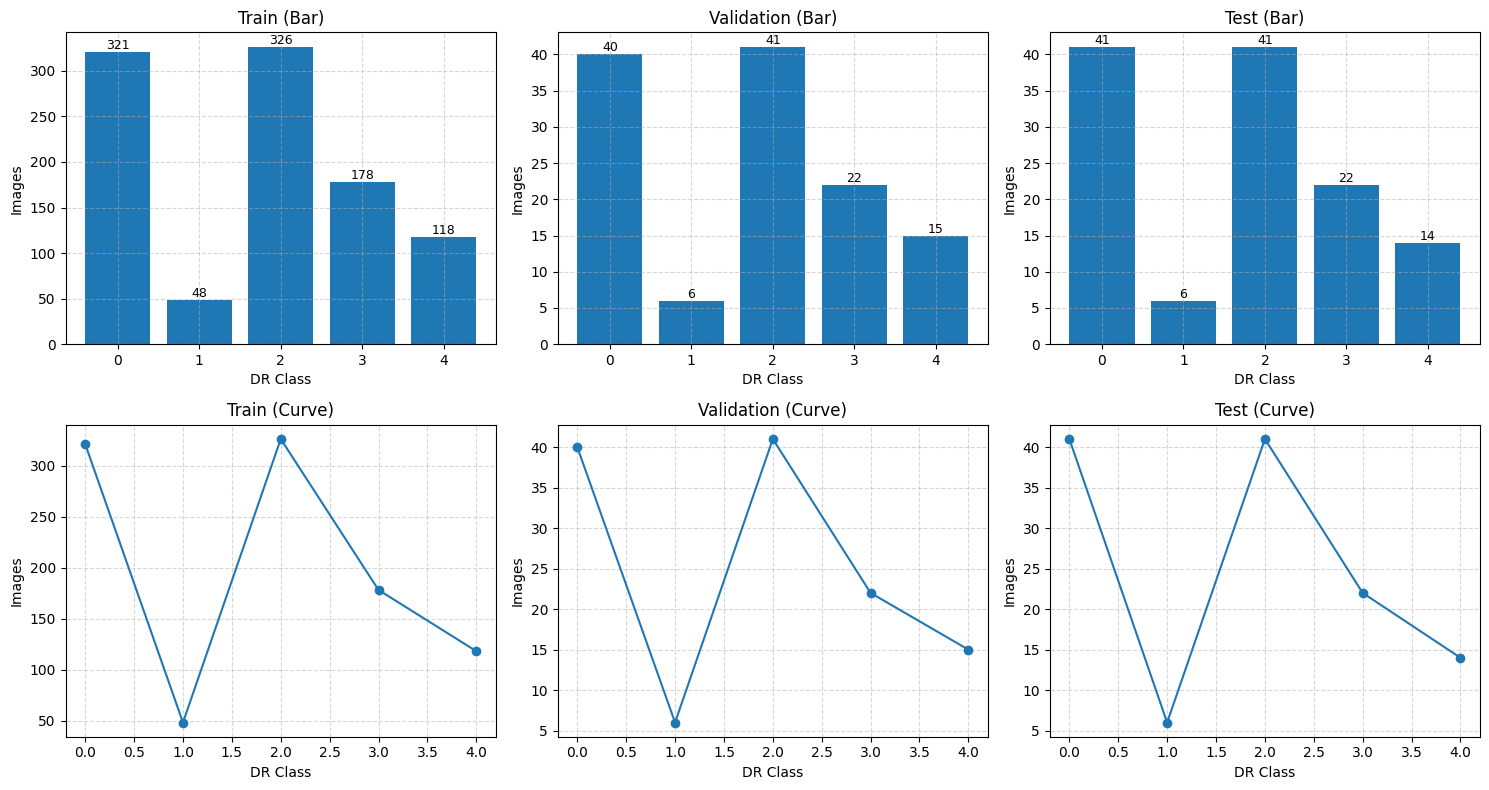


✅ Saved at: /content/drive/MyDrive/DR_New_Results/IDRiD/split_bar_and_curve_separate.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os

# =========================
# SAVE DIRECTORY
# =========================
base_path = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD"
)

os.makedirs(
    base_path,
    exist_ok=True
)

# =========================
# DATASET SPLIT
# =========================
train_df, temp_df = train_test_split(

    idrid_df,

    test_size=0.2,

    stratify=idrid_df["label"],

    random_state=42
)

val_df, test_df = train_test_split(

    temp_df,

    test_size=0.5,

    stratify=temp_df["label"],

    random_state=42
)

print("Train:", len(train_df))

print("Validation:", len(val_df))

print("Test:", len(test_df))

# =========================
# CLASS DISTRIBUTION
# =========================
split_counts = {

    "Train": train_df[
        "label"
    ].value_counts().sort_index(),

    "Validation": val_df[
        "label"
    ].value_counts().sort_index(),

    "Test": test_df[
        "label"
    ].value_counts().sort_index()
}

# =========================
# ADD VALUE LABELS
# =========================
def add_labels(ax):

    for patch in ax.patches:

        height = patch.get_height()

        ax.annotate(

            f'{int(height)}',

            (
                patch.get_x()
                + patch.get_width() / 2,

                height
            ),

            ha='center',

            va='bottom',

            fontsize=9
        )

# =========================
# APPLY COMMON STYLE
# =========================
def style_plot(ax, title):

    ax.set_title(title)

    ax.set_xlabel("DR Class")

    ax.set_ylabel("Images")

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

# =========================
# CREATE VISUALIZATION
# =========================
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,8)
)

# =========================
# BAR PLOTS
# =========================
for idx, (name, counts) in enumerate(
    split_counts.items()
):

    axes[0, idx].bar(

        counts.index,

        counts.values
    )

    add_labels(
        axes[0, idx]
    )

    style_plot(
        axes[0, idx],
        f"{name} (Bar)"
    )

# =========================
# CURVE PLOTS
# =========================
for idx, (name, counts) in enumerate(
    split_counts.items()
):

    axes[1, idx].plot(

        counts.index,

        counts.values,

        marker='o'
    )

    style_plot(
        axes[1, idx],
        f"{name} (Curve)"
    )

plt.tight_layout()

# =========================
# SAVE VISUALIZATION
# =========================
save_path = os.path.join(

    base_path,

    "split_bar_and_curve_separate.png"
)

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

print(
    f"\nSaved at: {save_path}"
)

**Visualization of Cleaned Train, Validation, and Test Distributions**

Missing images (Train): 0
Missing images (Val): 0
Missing images (Test): 0

Final Sizes → Train: 991 | Val: 124 | Test: 124


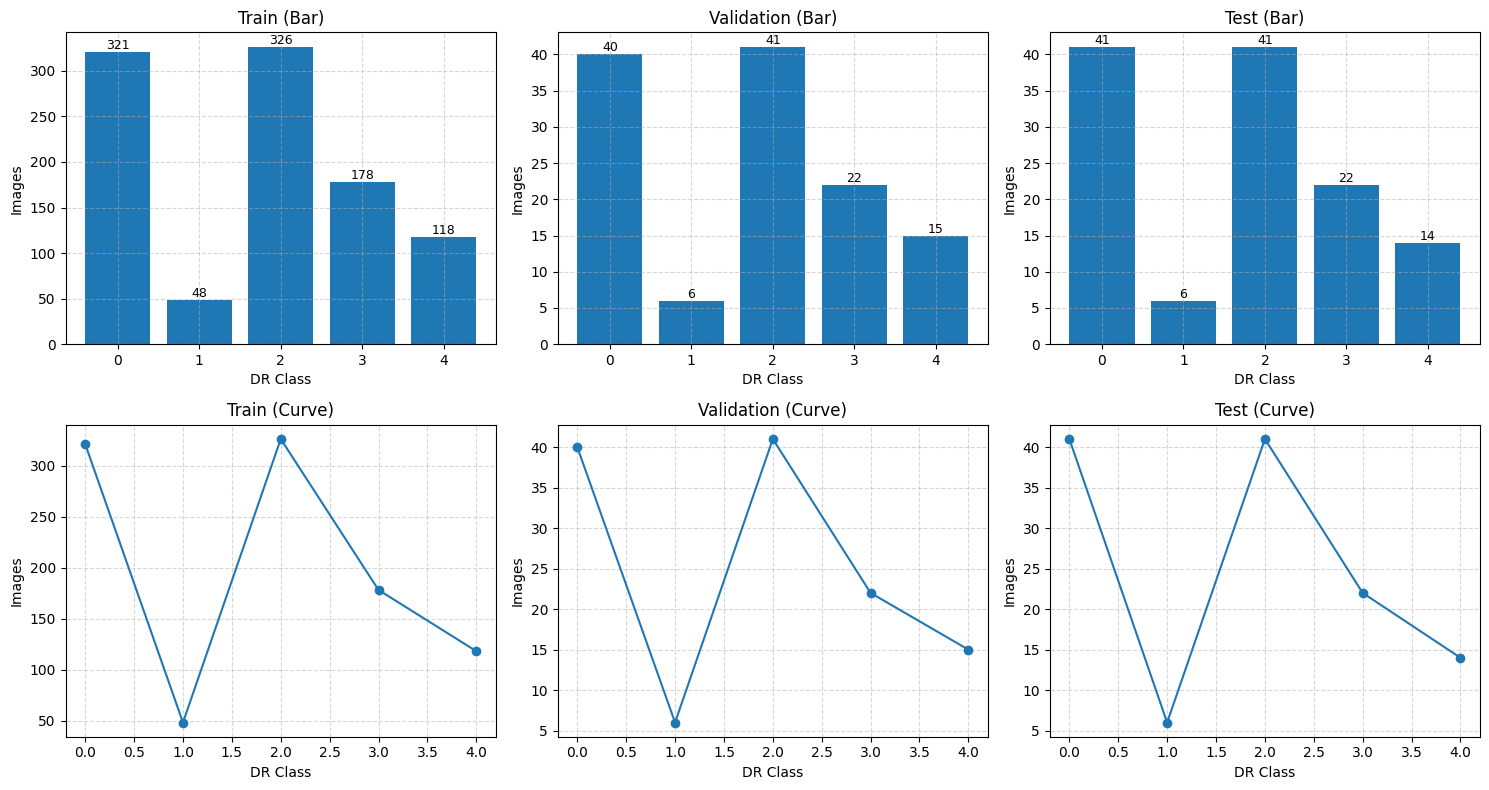


✅ Saved at: /content/drive/MyDrive/DR_New_Results/IDRiD/final_split_cleaned.png


In [ ]:
import os
import matplotlib.pyplot as plt

# =========================
# COPY DATAFRAMES
# =========================
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

# =========================
# IMAGE DIRECTORY
# =========================
image_folder = (
    "/content/drive/MyDrive/"
    "Dataset/IDRiD/Train/images"
)

# =========================
# BUILD IMAGE DICTIONARY
# =========================
image_dict = {

    os.path.splitext(file)[0]
    .strip()
    .lower():

    os.path.join(
        image_folder,
        file
    )

    for file in os.listdir(image_folder)

    if file.lower().endswith(
        (
            ".jpg",
            ".png",
            ".jpeg"
        )
    )
}

# =========================
# FIND IMAGE PATH
# =========================
def find_image(name):

    name = (
        os.path.splitext(
            str(name)
            .strip()
            .lower()
        )[0]
    )

    return image_dict.get(
        name,
        None
    )

# =========================
# MAP IMAGE PATHS
# =========================
for df in [train_df, val_df, test_df]:

    df["image_path"] = df[
        "Image name"
    ].apply(find_image)

# =========================
# CHECK MISSING FILES
# =========================
dataset_dict = {

    "Train": train_df,

    "Val": val_df,

    "Test": test_df
}

for name, df in dataset_dict.items():

    print(
        f"Missing images ({name}):",
        df["image_path"].isna().sum()
    )

# =========================
# CLEAN DATAFRAMES
# =========================
for name, df in dataset_dict.items():

    df = df.dropna(
        subset=["image_path"]
    )

    df = df[
        df["image_path"].apply(
            os.path.exists
        )
    ]

    if "label" not in df.columns:

        df.rename(
            columns={
                "Retinopathy grade": "label"
            },
            inplace=True
        )

    df["label"] = df[
        "label"
    ].astype(int)

    dataset_dict[name] = df.reset_index(
        drop=True
    )

# =========================
# UPDATE DATAFRAMES
# =========================
train_df = dataset_dict["Train"]
val_df = dataset_dict["Val"]
test_df = dataset_dict["Test"]

print(
    f"\nFinal Sizes → "
    f"Train: {len(train_df)} | "
    f"Val: {len(val_df)} | "
    f"Test: {len(test_df)}"
)

# =========================
# CLASS DISTRIBUTIONS
# =========================
split_counts = {

    "Train": train_df[
        "label"
    ].value_counts().sort_index(),

    "Validation": val_df[
        "label"
    ].value_counts().sort_index(),

    "Test": test_df[
        "label"
    ].value_counts().sort_index()
}

# =========================
# ADD VALUE LABELS
# =========================
def add_labels(ax):

    for patch in ax.patches:

        height = patch.get_height()

        ax.annotate(

            f'{int(height)}',

            (
                patch.get_x()
                + patch.get_width() / 2,

                height
            ),

            ha='center',

            va='bottom',

            fontsize=9
        )

# =========================
# APPLY COMMON STYLE
# =========================
def style_plot(ax, title):

    ax.set_title(title)

    ax.set_xlabel("DR Class")

    ax.set_ylabel("Images")

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

# =========================
# CREATE VISUALIZATION
# =========================
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,8)
)

# =========================
# BAR PLOTS
# =========================
for idx, (name, counts) in enumerate(
    split_counts.items()
):

    axes[0, idx].bar(

        counts.index,

        counts.values
    )

    add_labels(
        axes[0, idx]
    )

    style_plot(
        axes[0, idx],
        f"{name} (Bar)"
    )

# =========================
# CURVE PLOTS
# =========================
for idx, (name, counts) in enumerate(
    split_counts.items()
):

    axes[1, idx].plot(

        counts.index,

        counts.values,

        marker='o'
    )

    style_plot(
        axes[1, idx],
        f"{name} (Curve)"
    )

plt.tight_layout()

# =========================
# SAVE VISUALIZATION
# =========================
save_path = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD/"
    "final_split_cleaned.png"
)

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

print(
    f"\nSaved at: {save_path}"
)

**Visualization and Preprocessing Pipeline for the IDRiD Dataset**

Original (Imbalanced) Train Distribution:
label
2    326
0    321
3    178
4    118
1     48
Name: count, dtype: int64


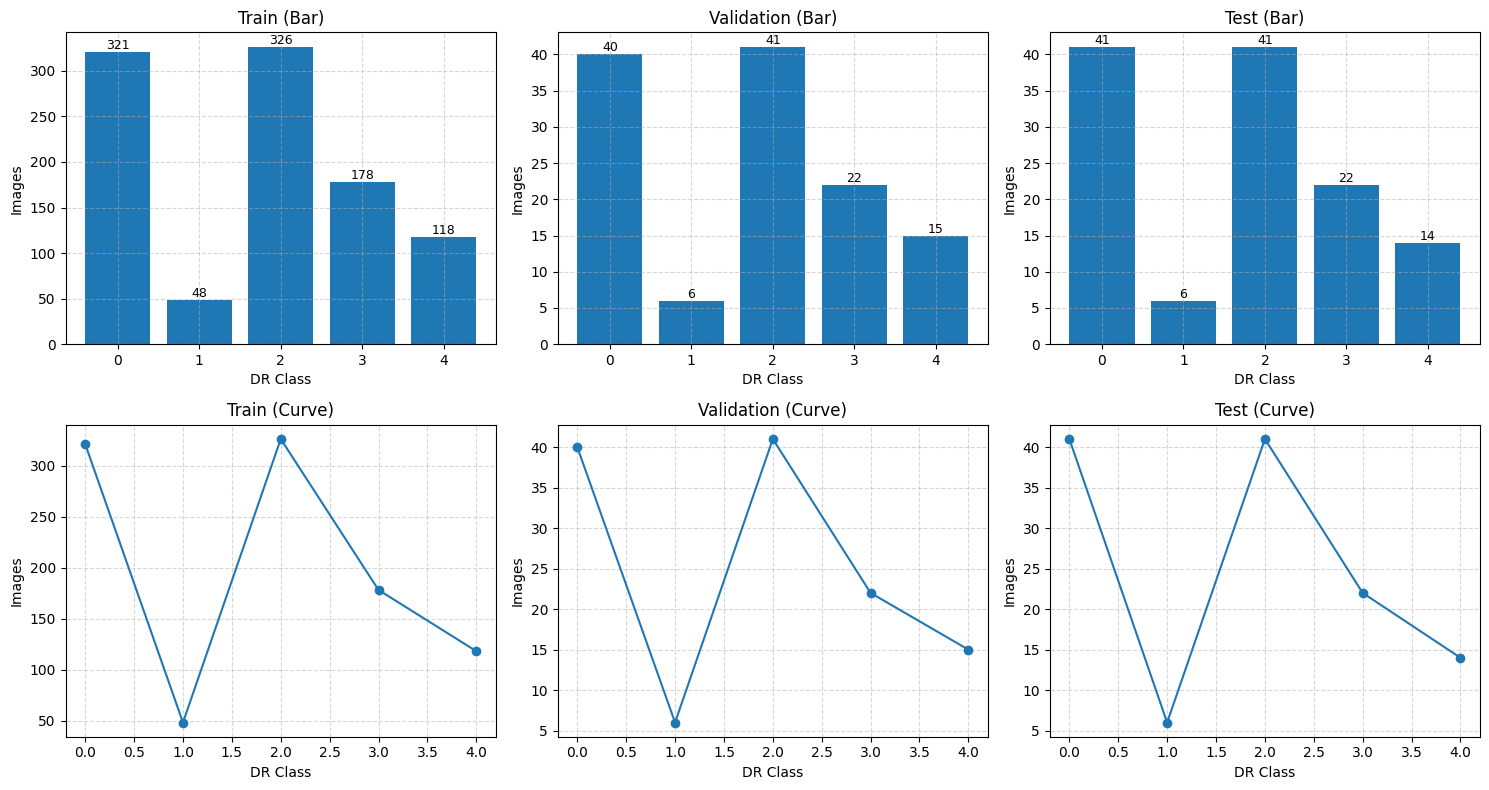


✅ Saved at: /content/drive/MyDrive/DR_New_Results/IDRiD/imbalanced_distribution.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import torch
import os

# =========================
# TRAIN DISTRIBUTION
# =========================
print(
    "Original (Imbalanced) "
    "Train Distribution:"
)

print(
    train_df["label"]
    .value_counts()
)

# =========================
# CLASS DISTRIBUTIONS
# =========================
split_counts = {

    "Train": train_df[
        "label"
    ].value_counts().sort_index(),

    "Validation": val_df[
        "label"
    ].value_counts().sort_index(),

    "Test": test_df[
        "label"
    ].value_counts().sort_index()
}

# =========================
# ADD VALUE LABELS
# =========================
def add_labels(ax):

    for patch in ax.patches:

        ax.annotate(

            f'{int(patch.get_height())}',

            (
                patch.get_x()
                + patch.get_width() / 2,

                patch.get_height()
            ),

            ha='center',

            va='bottom',

            fontsize=9
        )

# =========================
# APPLY COMMON STYLE
# =========================
def style_plot(ax, title):

    ax.set_title(title)

    ax.set_xlabel("DR Class")

    ax.set_ylabel("Images")

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

# =========================
# CREATE VISUALIZATION
# =========================
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,8)
)

# =========================
# BAR PLOTS
# =========================
for idx, (name, counts) in enumerate(
    split_counts.items()
):

    axes[0, idx].bar(

        counts.index,

        counts.values
    )

    add_labels(
        axes[0, idx]
    )

    style_plot(
        axes[0, idx],
        f"{name} (Bar)"
    )

# =========================
# CURVE PLOTS
# =========================
for idx, (name, counts) in enumerate(
    split_counts.items()
):

    axes[1, idx].plot(

        counts.index,

        counts.values,

        marker='o'
    )

    style_plot(
        axes[1, idx],
        f"{name} (Curve)"
    )

plt.tight_layout()

# =========================
# SAVE VISUALIZATION
# =========================
save_dir = (
    "/content/drive/MyDrive/"
    "DR_New_Results/IDRiD"
)

os.makedirs(
    save_dir,
    exist_ok=True
)

save_path = os.path.join(

    save_dir,

    "imbalanced_distribution.png"
)

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

print(
    f"\nSaved at: {save_path}"
)

# =========================
# IMAGE TRANSFORMS
# =========================
train_transform = transforms.Compose([

    transforms.Resize((320, 320)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        0.2,
        0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        [0.485, 0.456, 0.406],

        [0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((320, 320)),

    transforms.ToTensor(),

    transforms.Normalize(

        [0.485, 0.456, 0.406],

        [0.229, 0.224, 0.225]
    )
])

# =========================
# DATASET CLASS
# =========================
class DRDataset(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        df,
        transform=None
    ):

        self.df = df.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        try:

            image = Image.open(
                row["image_path"]
            ).convert("RGB")

        except:

            image = Image.new(
                "RGB",
                (320, 320)
            )

        label = int(
            row["label"]
        )

        if self.transform:

            image = self.transform(
                image
            )

        return image, label

# =========================
# CREATE DATASETS
# =========================
datasets = {

    "train_dataset": DRDataset(
        train_df,
        transform=train_transform
    ),

    "val_dataset": DRDataset(
        val_df,
        transform=val_transform
    ),

    "test_dataset": DRDataset(
        test_df,
        transform=val_transform
    )
}

train_dataset = datasets[
    "train_dataset"
]

val_dataset = datasets[
    "val_dataset"
]

test_dataset = datasets[
    "test_dataset"
]

DATA AUGMENTATION & preprocessing



In [ ]:
from torchvision import transforms

# =========================
# CONFIGURATION
# =========================
IMG_SIZE = 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# =========================
# NORMALIZATION
# =========================
normalize = transforms.Normalize(
    mean=imagenet_mean,
    std=imagenet_std
)

# =========================
# TRANSFORM FUNCTION
# =========================
def get_transforms(train=True):

    if train:
        return transforms.Compose([

            transforms.Resize((IMG_SIZE, IMG_SIZE)),

            transforms.RandomHorizontalFlip(p=0.5),

            transforms.RandomRotation(10),

            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.1,
                hue=0.03
            ),

            transforms.ToTensor(),

            normalize
        ])

    return transforms.Compose([

        transforms.Resize((IMG_SIZE, IMG_SIZE)),

        transforms.ToTensor(),

        normalize
    ])

# =========================
# FINAL TRANSFORMS
# =========================
train_transform = get_transforms(train=True)

val_transform = get_transforms(train=False)

DATASET PREPARATION


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import os

# =========================
# DIABETIC RETINOPATHY DATASET
# =========================
class DRDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)

        self.transform = transform

        # Keep only valid image paths
        self.valid_indices = [

            idx for idx in range(len(self.dataframe))

            if os.path.exists(
                self.dataframe.loc[idx, "image_path"]
            )
        ]

        print(f"Valid Images: {len(self.valid_indices)}")

    def __len__(self):

        return len(self.valid_indices)

    def __getitem__(self, idx):

        real_idx = self.valid_indices[idx]

        image_path = self.dataframe.loc[
            real_idx,
            "image_path"
        ]

        label = int(
            self.dataframe.loc[real_idx, "label"]
        )

        try:
            image = Image.open(image_path).convert("RGB")

        except Exception:

            # Fallback image (prevents training crash)
            image = Image.new("RGB", (224, 224))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(
            label,
            dtype=torch.long
        )

In [ ]:
train_dataset = DRDataset(train_df, transform=train_transform)
val_dataset   = DRDataset(val_df, transform=val_transform)
test_dataset  = DRDataset(test_df, transform=val_transform)

Valid images: 991
Valid images: 124
Valid images: 124


 Data Loaders

In [ ]:
# Data Loaders

from torch.utils.data import DataLoader
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Auto settings
is_cuda = device.type == "cuda"

batch_size = 16 if is_cuda else 8
num_workers = 2 if is_cuda else 0
pin_memory = is_cuda
persistent_workers = num_workers > 0

# Common loader settings
loader_args = dict(
    batch_size=batch_size,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers
)

# Train loader
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    **loader_args
)

# Validation loader
val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_args
)

# Test loader
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_args
)

**Model Architecture**

In [ ]:
# Model

import torch
import torch.nn as nn
from torchvision.models import (
    efficientnet_b4,
    EfficientNet_B4_Weights
)

# =========================
# CROSS PATCH ATTENTION
# =========================
class CrossPatchAttention(nn.Module):

    def __init__(self, channels):
        super().__init__()

        reduced_channels = channels // 8

        self.query = nn.Conv2d(
            channels,
            reduced_channels,
            kernel_size=1
        )

        self.key = nn.Conv2d(
            channels,
            reduced_channels,
            kernel_size=1
        )

        self.value = nn.Conv2d(
            channels,
            channels,
            kernel_size=1
        )

        self.gamma = nn.Parameter(
            torch.zeros(1)
        )

    def forward(self, x):

        B, C, H, W = x.shape

        q = self.query(x).flatten(2)
        k = self.key(x).flatten(2)
        v = self.value(x).flatten(2)

        attention = torch.softmax(
            torch.bmm(q.transpose(1, 2), k),
            dim=-1
        )

        out = torch.bmm(
            v,
            attention.transpose(1, 2)
        )

        out = out.view(B, C, H, W)

        return self.gamma * out + x


# =========================
# REGION ATTENTION
# =========================
class RegionAttention(nn.Module):

    def __init__(self, channels):
        super().__init__()

        reduced_channels = channels // 4

        self.attention = nn.Sequential(

            nn.Conv2d(
                channels,
                reduced_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                reduced_channels,
                channels,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        return x * self.attention(x)


# =========================
# FINAL MODEL
# =========================
class DRModel(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        backbone = efficientnet_b4(
            weights=EfficientNet_B4_Weights.IMAGENET1K_V1
        )

        self.features = backbone.features

        channels = 1792

        # Freeze early layers
        for param in self.features[:6].parameters():
            param.requires_grad = False

        self.cross_attention = CrossPatchAttention(channels)

        self.region_attention = RegionAttention(channels)

        self.feature_dropout = nn.Dropout2d(0.1)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(

            nn.LayerNorm(channels),

            nn.Linear(channels, 512),

            nn.GELU(),

            nn.Dropout(0.4),

            nn.LayerNorm(512),

            nn.Linear(512, 256),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.cross_attention(x)

        x = self.region_attention(x)

        x = self.feature_dropout(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        return self.head(x)

**Model Training**

In [ ]:
# Model Training

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.metrics import cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

import numpy as np
import os

# =========================
# DEVICE
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

# =========================
# PATHS
# =========================
RESULT_PATH = "/content/drive/MyDrive/DR_New_Results/IDRiD"

os.makedirs(RESULT_PATH, exist_ok=True)

best_model_path = os.path.join(
    RESULT_PATH,
    "best_model.pth"
)

# =========================
# DATALOADER SETTINGS
# =========================
loader_args = dict(
    batch_size=12,
    num_workers=2,
    pin_memory=True
)

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_args
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_args
)

# =========================
# MODEL
# =========================
model = DRModel(
    num_classes=5
).to(device)

# =========================
# CLASS WEIGHTS
# =========================
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

# =========================
# FOCAL LOSS
# =========================
class FocalLoss(nn.Module):

    def __init__(self, gamma=2, weight=None):

        super().__init__()

        self.gamma = gamma

        self.ce = nn.CrossEntropyLoss(
            weight=weight,
            reduction="none"
        )

    def forward(self, inputs, targets):

        ce_loss = self.ce(inputs, targets)

        pt = torch.exp(-ce_loss)

        return (
            ((1 - pt) ** self.gamma) * ce_loss
        ).mean()


criterion = FocalLoss(weight=weights)

# =========================
# OPTIMIZER
# =========================
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

# =========================
# AMP
# =========================
use_amp = device.type == "cuda"

scaler = torch.cuda.amp.GradScaler(
    enabled=use_amp
)

# =========================
# TRAINING LOOP
# =========================
best_qwk = 0

num_epochs = 10

for epoch in range(num_epochs):

    # ===== TRAIN =====
    model.train()

    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(
            enabled=use_amp
        ):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)

        scaler.update()

        train_loss += loss.item()

    # ===== VALIDATION =====
    model.eval()

    all_preds = []

    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            out_original = model(images)

            out_flipped = model(
                torch.flip(images, dims=[3])
            )

            outputs = (
                out_original + out_flipped
            ) / 2

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    qwk = cohen_kappa_score(
        all_labels,
        all_preds,
        weights="quadratic"
    )

    scheduler.step()

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"QWK: {qwk:.4f}")

    # ===== SAVE BEST MODEL =====
    if qwk > best_qwk:

        best_qwk = qwk

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("✓ Best model saved")

print(f"\n🏆 FINAL BEST QWK: {best_qwk:.4f}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 140MB/s]
/tmp/ipykernel_2728/2301073555.py:91: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_2728/2301073555.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 1/10
Train Loss: 90.4733
QWK: 0.2193
✓ Best model saved


/tmp/ipykernel_2728/2301073555.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 2/10
Train Loss: 82.0613
QWK: 0.6025
✓ Best model saved


...


Epoch 8/10
Train Loss: 53.7073
QWK: 0.7142


/tmp/ipykernel_2728/2301073555.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 9/10
Train Loss: 53.2066
QWK: 0.7026


/tmp/ipykernel_2728/2301073555.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 10/10
Train Loss: 51.4025
QWK: 0.7402
✓ Best model saved

🏆 FINAL BEST QWK: 0.7402


**Data Leakage Check**

In [ ]:
train_set = set(train_df["image_path"])
val_set   = set(val_df["image_path"])
test_set  = set(test_df["image_path"])

print("Train-Val overlap:", len(train_set & val_set))
print("Train-Test overlap:", len(train_set & test_set))
print("Val-Test overlap:", len(val_set & test_set))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [ ]:
test_loader = DataLoader(
    DRDataset(test_df, transform=val_transform),
    batch_size=16,
    shuffle=False
)

Valid images: 124


**Evaluation**

In [ ]:
# Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

# =========================
# METRICS
# =========================
metrics = {
    "Accuracy": accuracy_score(
        all_labels,
        all_preds
    ),

    "QWK": cohen_kappa_score(
        all_labels,
        all_preds,
        weights="quadratic"
    )
}

print("\nFINAL TEST RESULTS")

for name, value in metrics.items():

    print(f"{name}: {value:.4f}")

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_preds
    )
)

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(
    all_labels,
    all_preds
)

print("\nConfusion Matrix:\n", cm)


🔥 FINAL TEST RESULTS
Accuracy: 0.4355
QWK: 0.7439

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.44      0.56        41
           1       0.17      0.67      0.28         6
           2       0.65      0.37      0.47        41
           3       0.24      0.18      0.21        22
           4       0.34      0.93      0.50        14

    accuracy                           0.44       124
   macro avg       0.44      0.52      0.40       124
weighted avg       0.56      0.44      0.45       124


Confusion Matrix:
 [[18 17  4  2  0]
 [ 1  4  1  0  0]
 [ 4  2 15 11  9]
 [ 0  0  2  4 16]
 [ 0  0  1  0 13]]


**Final Evaluation**


🔥 FINAL TEST RESULTS
Accuracy : 0.4355
Precision: 0.5632
Recall   : 0.4355
F1 Score : 0.4472
QWK      : 0.7439

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.44      0.56        41
           1       0.17      0.67      0.28         6
           2       0.65      0.37      0.47        41
           3       0.24      0.18      0.21        22
           4       0.34      0.93      0.50        14

    accuracy                           0.44       124
   macro avg       0.44      0.52      0.40       124
weighted avg       0.56      0.44      0.45       124



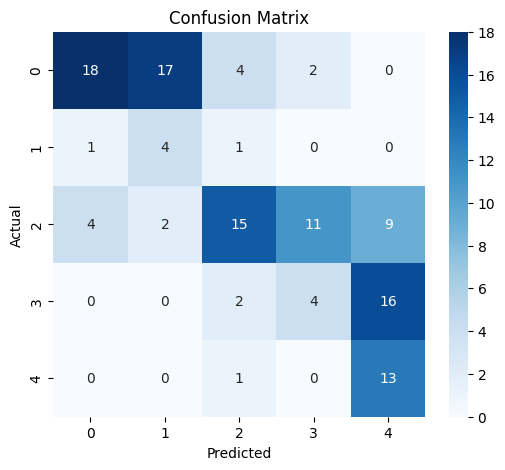


✅ Confusion matrix saved at: /content/drive/MyDrive/DR_New_Results/IDRiD/confusion_matrix.png


In [ ]:
# Final Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

import torch
import os

# =========================
# LOAD BEST MODEL
# =========================
model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.to(device)

model.eval()

# =========================
# TEST PREDICTIONS
# =========================
y_true = []

y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

# =========================
# METRICS
# =========================
metrics = {

    "Accuracy": accuracy_score(
        y_true,
        y_pred
    ),

    "Precision": precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    ),

    "Recall": recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    ),

    "QWK": cohen_kappa_score(
        y_true,
        y_pred,
        weights="quadratic"
    )
}

print("\nFINAL TEST RESULTS")

for name, value in metrics.items():

    print(f"{name}: {value:.4f}")

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

# =========================
# SAVE RESULTS
# =========================
save_dir = "/content/drive/MyDrive/DR_New_Results/IDRiD"

os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "confusion_matrix.png"
)

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

print(f"\nConfusion matrix saved at: {save_path}")

Save Results

In [ ]:
# Save Results

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# =========================
# PATH
# =========================
RESULTS_PATH = "/content/drive/MyDrive/DR_New_Results/IDRiD"

os.makedirs(
    RESULTS_PATH,
    exist_ok=True
)

# =========================
# SAVE FUNCTION
# =========================
def save_plot(filename):

    plt.savefig(
        os.path.join(RESULTS_PATH, filename),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


def save_all_results(
    y_true,
    y_pred,
    accuracy,
    precision,
    recall,
    f1,
    kappa
):

    # =========================
    # CONFUSION MATRIX
    # =========================
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.title("Confusion Matrix")

    save_plot("confusion_matrix.png")

    # =========================
    # METRICS TABLE
    # =========================
    metrics_data = [

        ["Accuracy", f"{accuracy:.4f}"],

        ["Precision", f"{precision:.4f}"],

        ["Recall", f"{recall:.4f}"],

        ["F1-Score", f"{f1:.4f}"],

        ["QWK", f"{kappa:.4f}"]
    ]

    fig, ax = plt.subplots(figsize=(4, 2))

    ax.axis("off")

    table = ax.table(
        cellText=metrics_data,
        colLabels=["Metric", "Value"],
        loc="center"
    )

    table.auto_set_font_size(False)

    table.set_fontsize(10)

    table.scale(1, 1.5)

    save_plot("evaluation_metrics.png")

    # =========================
    # CLASSIFICATION REPORT
    # =========================
    report = classification_report(
        y_true,
        y_pred,
        zero_division=0
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.axis("off")

    ax.text(
        0,
        1,
        report,
        fontsize=10,
        family="monospace",
        va="top"
    )

    save_plot("classification_report.png")

    # =========================
    # PREDICTION DISTRIBUTION
    # =========================
    plt.figure(figsize=(6, 4))

    plt.hist(
        y_pred,
        bins=np.arange(6) - 0.5,
        rwidth=0.8
    )

    plt.xticks(range(5))

    plt.xlabel("Predicted Class")

    plt.ylabel("Frequency")

    plt.title("Prediction Distribution")

    save_plot("prediction_distribution.png")

    # =========================
    # TRUE VS PREDICTED
    # =========================
    plt.figure(figsize=(6, 4))

    plt.hist(
        y_true,
        bins=np.arange(6) - 0.5,
        alpha=0.6,
        label="True"
    )

    plt.hist(
        y_pred,
        bins=np.arange(6) - 0.5,
        alpha=0.6,
        label="Predicted"
    )

    plt.legend()

    plt.xticks(range(5))

    plt.title("True vs Predicted Distribution")

    save_plot("true_vs_pred.png")

    print(f"All results saved in: {RESULTS_PATH}")


# =========================
# CALL FUNCTION
# =========================
save_all_results(
    y_true,
    y_pred,
    accuracy,
    precision,
    recall,
    f1,
    qwk
)

✅ All results saved in: /content/drive/MyDrive/DR_New_Results/IDRiD


Ablation study

In [ ]:
# Ablation Study

import os
import time

import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import timm

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score
)

# =========================
# DEVICE
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using: {device}")

# =========================
# SAVE PATH
# =========================
SAVE_PATH = "/content/drive/MyDrive/DR_New_Results/IDRiD/ablation_5epoch"

os.makedirs(
    SAVE_PATH,
    exist_ok=True
)

# =========================
# MODEL
# =========================
class DRModel(nn.Module):

    def __init__(
        self,
        use_cross=False,
        use_region=False
    ):

        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=True,
            num_classes=0
        )

        channels = self.backbone.num_features

        self.use_cross = use_cross

        self.use_region = use_region

        self.cross = nn.Conv2d(
            channels,
            channels,
            kernel_size=1
        )

        self.region = nn.Sequential(

            nn.Conv2d(
                channels,
                1,
                kernel_size=3,
                padding=1
            ),

            nn.Sigmoid()
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(
            channels,
            5
        )

    def forward(self, x):

        x = self.backbone.forward_features(x)

        if self.use_cross:
            x = x + self.cross(x)

        if self.use_region:
            x = x * self.region(x)

        x = self.pool(x).flatten(1)

        return self.fc(x)

# =========================
# PARAMETER COUNT
# =========================
def count_params(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

# =========================
# TRAIN + VALIDATION
# =========================
def train_model(
    config,
    name,
    epochs=5
):

    model = DRModel(
        **config
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=3e-5
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    # Class weights
    class_counts = (
        train_df["label"]
        .value_counts()
        .sort_index()
    )

    weights = torch.tensor(
        1.0 / class_counts.values,
        dtype=torch.float32
    ).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=weights
    )

    start = time.time()

    # =========================
    # TRAINING
    # =========================
    for epoch in range(epochs):

        model.train()

        for images, labels in train_loader:

            images, labels = (
                images.to(device),
                labels.to(device)
            )

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

        scheduler.step()

        print(
            f"{name} "
            f"Epoch {epoch+1}/{epochs} done"
        )

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    preds = []

    true = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            preds.extend(
                predictions.cpu().numpy()
            )

            true.extend(
                labels.numpy()
            )

    end = time.time()

    # =========================
    # METRICS
    # =========================
    metrics = {

        "Accuracy": accuracy_score(
            true,
            preds
        ),

        "F1-Score": f1_score(
            true,
            preds,
            average="weighted"
        ),

        "QWK": cohen_kappa_score(
            true,
            preds,
            weights="quadratic"
        )
    }

    params = round(
        count_params(model) / 1e6,
        2
    )

    total_time = round(
        end - start,
        2
    )

    return (
        metrics,
        params,
        total_time
    )

# =========================
# EXPERIMENTS
# =========================
experiments = {

    "Baseline": {
        "use_cross": False,
        "use_region": False
    },

    "Cross": {
        "use_cross": True,
        "use_region": False
    },

    "Region": {
        "use_cross": False,
        "use_region": True
    },

    "Full (Proposed)": {
        "use_cross": True,
        "use_region": True
    }
}

results = []

# =========================
# RUN ABLATION
# =========================
for name, config in experiments.items():

    print(f"\nRunning {name}")

    metrics, params, total_time = train_model(
        config,
        name,
        epochs=5
    )

    results.append({

        "Model": name,

        "Accuracy": round(
            metrics["Accuracy"],
            4
        ),

        "F1-Score": round(
            metrics["F1-Score"],
            4
        ),

        "QWK": round(
            metrics["QWK"],
            4
        ),

        "Params (M)": params,

        "Time (s)": total_time
    })

# =========================
# SAVE RESULTS
# =========================
results_df = pd.DataFrame(results)

print("\nFINAL RESULTS\n")

print(results_df)

csv_path = os.path.join(
    SAVE_PATH,
    "ablation_5epoch.csv"
)

results_df.to_csv(
    csv_path,
    index=False
)

print(f"\nSaved: {csv_path}")

Using: cpu

🚀 Running Baseline
Baseline Epoch 1/5 done
Baseline Epoch 2/5 done
Baseline Epoch 3/5 done
Baseline Epoch 4/5 done
Baseline Epoch 5/5 done

🚀 Running Cross


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Cross Epoch 1/5 done
Cross Epoch 2/5 done
Cross Epoch 3/5 done
Cross Epoch 4/5 done
Cross Epoch 5/5 done

🚀 Running Region


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Region Epoch 1/5 done
Region Epoch 2/5 done
Region Epoch 3/5 done
Region Epoch 4/5 done
Region Epoch 5/5 done

🚀 Running Full (Proposed)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Full (Proposed) Epoch 1/5 done
Full (Proposed) Epoch 2/5 done
Full (Proposed) Epoch 3/5 done
Full (Proposed) Epoch 4/5 done
Full (Proposed) Epoch 5/5 done

🔥 FINAL RESULTS

             Model  Accuracy  F1-Score     QWK  Params (M)  Time (s)
0         Baseline    0.5215    0.5141  0.6407        5.67   1693.26
1            Cross    0.5269    0.5318  0.7217        5.67   1739.35
2           Region    0.4462    0.3990  0.6797        5.67   1675.75
3  Full (Proposed)    0.5484    0.5535  0.6987        5.67   1677.85

✅ Saved: /content/drive/MyDrive/DR_New_Results/IDRiD/ablation_5epoch/ablation_5epoch.csv
